# Entrega 1 — Entendimiento del negocio y de los datos
## Anexo de código: procesamiento en clúster Apache Spark

**Proyecto:** Plan de acción para la reducción de arrestos y siniestros viales en Nueva York  
**Equipo consultor:** Aldana · Ávila · Pardo  
**Clúster:** Apache Spark 4.2.0 standalone — 6 nodos, 24 núcleos, 86 GB de RAM

---

Este cuaderno contiene el procesamiento que sustenta las cifras presentadas en el documento
escrito. Cada apartado del documento tiene aquí su celda de código correspondiente.

> **Requisito de ejecución:** seleccionar el kernel `PySpark 4.2 (Python 3.11)`.
> Dicho kernel define `PYSPARK_PYTHON=/opt/cluster/python311/bin/python3`, necesario porque
> PySpark 4.2 requiere Python 3.10 o superior mientras que el intérprete del sistema es 3.9.


## 1. Inicialización de la sesión de Spark


In [1]:
import time, re
from pyspark.sql import SparkSession, functions as F
from pyspark.sql.types import (StructType, StructField, StringType,
                               IntegerType, DoubleType)
import pandas as pd

pd.set_option('display.max_rows', 120)
pd.set_option('display.width', 200)

spark = (SparkSession.builder
         .appName('NY_Entrega1_Aldana_Avila_Pardo')
         .config('spark.sql.session.timeZone', 'America/New_York')
         .getOrCreate())

spark.sparkContext.setLogLevel('ERROR')

print('Version de Spark :', spark.version)
print('Maestro          :', spark.sparkContext.master)
print('Aplicacion       :', spark.sparkContext.applicationId)


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
/opt/cluster/spark/python/pyspark/testing/utils.py:127: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


Version de Spark : 4.2.0
Maestro          : spark://10.43.97.58:7077
Aplicacion       : app-20260920201454-0038


Se consulta la interfaz de administración del nodo maestro para documentar la capacidad
total del clúster. Conviene advertir que el número de *ejecutores* activos no coincide con
el de *nodos trabajadores*: al estar habilitada la asignación dinámica
(`spark.dynamicAllocation.enabled`), Spark no solicita ejecutores mientras no exista trabajo
pendiente. Por ese motivo la ocupación real se mide más adelante, una vez ejecutado el
procesamiento.


In [2]:
import json
from urllib.request import urlopen

def capacidad_cluster(url='http://10.43.97.58:8081/json/'):
    with urlopen(url, timeout=15) as r:
        j = json.loads(r.read().decode())
    vivos = [w for w in j.get('workers', []) if w.get('state') == 'ALIVE']
    return pd.DataFrame([{'Nodo': w['host'],
                          'Nucleos': w['cores'],
                          'Memoria (MB)': w['memory'],
                          'Estado': w['state']} for w in vivos]), j

cap, crudo = capacidad_cluster()
print('Estado del maestro :', crudo['status'])
print('Nucleos totales    :', crudo['cores'])
print('Memoria total (MB) :', crudo['memory'])
cap


Estado del maestro : ALIVE
Nucleos totales    : 24
Memoria total (MB) : 88056


,Nodo,Nucleos,Memoria (MB),Estado
0,10.43.97.67,4,14676,ALIVE
1,10.43.97.63,4,14676,ALIVE
2,10.43.97.59,4,14676,ALIVE
3,10.43.97.71,4,14676,ALIVE
4,10.43.97.58,4,14676,ALIVE
5,10.43.97.61,4,14676,ALIVE


In [3]:
def ejecutores_activos():
    """Ejecutores asignados a la aplicacion en este instante.

    La interfaz Java SparkExecutorInfo de Spark 4.2 expone host() y port(),
    pero no executorId(); la identidad del ejecutor se deriva de host:puerto.
    La primera entrada corresponde al proceso conductor (driver).
    """
    def corto(h):
        # Los nodos se reportan indistintamente por nombre de dominio o por IP
        return h if re.match(r'^\d+\.\d+\.\d+\.\d+$', h) else h.split('.')[0]
    infos = spark.sparkContext._jsc.sc().statusTracker().getExecutorInfos()
    return len(infos), sorted({corto(e.host()) for e in infos})

n, nodos = ejecutores_activos()
print('Entradas de ejecutor antes de procesar:', n)
print('Nodos                                 :', nodos)


Entradas de ejecutor antes de procesar: 1
Nodos                                 : ['NBDG41']


## 2. Colección de datos

Los siete conjuntos residen en el directorio `/opt/cluster/data/grupo1`, exportado por NFS
desde el nodo maestro y montado en la misma ruta por los seis nodos, de modo que todos los
ejecutores acceden a los archivos mediante una ruta idéntica.

Se declaran **esquemas explícitos** en lugar de recurrir a `inferSchema`. Esto evita una
pasada adicional de lectura sobre archivos de gran tamaño y, sobre todo, impide que Spark
infiera tipos incorrectos en columnas como los puntajes SAT, que contienen el marcador `s`
para los valores suprimidos por confidencialidad.


In [4]:
BASE = '/opt/cluster/data/grupo1'

def leer(nombre, esquema=None, multilinea=False, inferir=False):
    """Lectura estandarizada de archivos CSV con cabecera."""
    lector = (spark.read
              .option('header', True)
              .option('quote', '"')
              .option('escape', '"')
              .option('multiLine', multilinea)
              .option('mode', 'PERMISSIVE'))
    if esquema is not None:
        lector = lector.schema(esquema)
    elif inferir:
        lector = lector.option('inferSchema', True)
    return lector.csv(BASE + '/' + nombre)

def esquema_de(pares):
    return StructType([StructField(n, t, True) for n, t in pares])

S, I, D = StringType(), IntegerType(), DoubleType()


### 2.1 Arrestos del NYPD

Los conjuntos histórico y del año en curso comparten las primeras dieciocho columnas. La
diferencia está en la última: el histórico la denomina `Lon_Lat` y el del año en curso
`Location`, aunque ambas contienen la misma geometría en formato `POINT (lon lat)`. Se
normaliza el nombre a `geo_punto` antes de cualquier unificación, pues de lo contrario la
unión de ambas tablas produciría un desplazamiento silencioso de columnas.


In [5]:
COLS_ARRESTO = [
    ('ARREST_KEY', S), ('ARREST_DATE', S), ('PD_CD', I), ('PD_DESC', S),
    ('KY_CD', I), ('OFNS_DESC', S), ('LAW_CODE', S), ('LAW_CAT_CD', S),
    ('ARREST_BORO', S), ('ARREST_PRECINCT', I), ('JURISDICTION_CODE', I),
    ('AGE_GROUP', S), ('PERP_SEX', S), ('PERP_RACE', S),
    ('X_COORD_CD', D), ('Y_COORD_CD', D), ('Latitude', D), ('Longitude', D),
]

esq_hist = esquema_de(COLS_ARRESTO + [('Lon_Lat', S)])
esq_ytd  = esquema_de(COLS_ARRESTO + [('Location', S)])

arr_hist = leer('nypd_arrests_historic.csv', esq_hist).withColumnRenamed('Lon_Lat', 'geo_punto')
arr_ytd  = leer('nypd_arrests_ytd.csv',      esq_ytd ).withColumnRenamed('Location', 'geo_punto')

# La fecha viene en formato MM/dd/yyyy; sin conversion explicita permaneceria como texto
arr_hist = arr_hist.withColumn('ARREST_DATE', F.to_date('ARREST_DATE', 'MM/dd/yyyy'))
arr_ytd  = arr_ytd.withColumn('ARREST_DATE',  F.to_date('ARREST_DATE',  'MM/dd/yyyy'))

print('Esquemas compatibles para union:', arr_hist.columns == arr_ytd.columns)


Esquemas compatibles para union: True


### 2.2 Siniestros viales

El conjunto *Crashes* registra un siniestro por fila y aporta la ubicación y la gravedad. El
conjunto *Vehicles* registra un vehículo por fila y aporta las circunstancias del hecho.
Ambos se relacionan mediante el atributo `COLLISION_ID`.

*Crashes* se lee con `multiLine=True` porque contiene un registro con un salto de línea
embebido dentro de un nombre de calle. Sin esa opción, Spark divide ese registro en dos
filas defectuosas y el conteo total resulta alterado.


In [6]:
COLS_CRASH = [
    ('CRASH DATE', S), ('CRASH TIME', S), ('BOROUGH', S), ('ZIP CODE', S),
    ('LATITUDE', D), ('LONGITUDE', D), ('LOCATION', S),
    ('ON STREET NAME', S), ('CROSS STREET NAME', S), ('OFF STREET NAME', S),
    ('NUMBER OF PERSONS INJURED', I), ('NUMBER OF PERSONS KILLED', I),
    ('NUMBER OF PEDESTRIANS INJURED', I), ('NUMBER OF PEDESTRIANS KILLED', I),
    ('NUMBER OF CYCLIST INJURED', I), ('NUMBER OF CYCLIST KILLED', I),
    ('NUMBER OF MOTORIST INJURED', I), ('NUMBER OF MOTORIST KILLED', I),
    ('CONTRIBUTING FACTOR VEHICLE 1', S), ('CONTRIBUTING FACTOR VEHICLE 2', S),
    ('CONTRIBUTING FACTOR VEHICLE 3', S), ('CONTRIBUTING FACTOR VEHICLE 4', S),
    ('CONTRIBUTING FACTOR VEHICLE 5', S), ('COLLISION_ID', I),
    ('VEHICLE TYPE CODE 1', S), ('VEHICLE TYPE CODE 2', S),
    ('VEHICLE TYPE CODE 3', S), ('VEHICLE TYPE CODE 4', S),
    ('VEHICLE TYPE CODE 5', S),
]

def a_snake(c):
    return (c.lower().replace(' ', '_')
             .replace('number_of_', 'n_')
             .replace('contributing_factor_vehicle_', 'factor_')
             .replace('vehicle_type_code_', 'tipo_veh_'))

crashes = leer('mvc_crashes.csv', esquema_de(COLS_CRASH), multilinea=True)
crashes = crashes.toDF(*[a_snake(c) for c in crashes.columns])
crashes = crashes.withColumn('crash_date', F.to_date('crash_date', 'MM/dd/yyyy'))

print('Atributos de crashes:')
print(crashes.columns)


Atributos de crashes:
['crash_date', 'crash_time', 'borough', 'zip_code', 'latitude', 'longitude', 'location', 'on_street_name', 'cross_street_name', 'off_street_name', 'n_persons_injured', 'n_persons_killed', 'n_pedestrians_injured', 'n_pedestrians_killed', 'n_cyclist_injured', 'n_cyclist_killed', 'n_motorist_injured', 'n_motorist_killed', 'factor_1', 'factor_2', 'factor_3', 'factor_4', 'factor_5', 'collision_id', 'tipo_veh_1', 'tipo_veh_2', 'tipo_veh_3', 'tipo_veh_4', 'tipo_veh_5']


In [7]:
COLS_VEH = [
    ('UNIQUE_ID', I), ('COLLISION_ID', I), ('CRASH_DATE', S), ('CRASH_TIME', S),
    ('VEHICLE_ID', S), ('STATE_REGISTRATION', S), ('VEHICLE_TYPE', S),
    ('VEHICLE_MAKE', S), ('VEHICLE_MODEL', S), ('VEHICLE_YEAR', S),
    ('TRAVEL_DIRECTION', S), ('VEHICLE_OCCUPANTS', I), ('DRIVER_SEX', S),
    ('DRIVER_LICENSE_STATUS', S), ('DRIVER_LICENSE_JURISDICTION', S),
    ('PRE_CRASH', S), ('POINT_OF_IMPACT', S), ('VEHICLE_DAMAGE', S),
    ('VEHICLE_DAMAGE_1', S), ('VEHICLE_DAMAGE_2', S), ('VEHICLE_DAMAGE_3', S),
    ('PUBLIC_PROPERTY_DAMAGE', S), ('PUBLIC_PROPERTY_DAMAGE_TYPE', S),
    ('CONTRIBUTING_FACTOR_1', S), ('CONTRIBUTING_FACTOR_2', S),
]

vehiculos = leer('mvc_vehicles.csv', esquema_de(COLS_VEH))
vehiculos = vehiculos.toDF(*[c.lower() for c in vehiculos.columns])
vehiculos = vehiculos.withColumn('crash_date', F.to_date('crash_date', 'MM/dd/yyyy'))

print('Atributos de vehiculos:', len(vehiculos.columns))


Atributos de vehiculos: 25


### 2.3 Pobreza y educación

La medida de pobreza corresponde a microdatos a nivel de persona derivados de la *American
Community Survey*, con 61 variables codificadas numéricamente. Los puntajes SAT se leen
deliberadamente como texto: el conjunto emplea el marcador `s` para las instituciones con
menos de cinco evaluados, de modo que una conversión automática generaría nulos silenciosos.


In [8]:
pobreza = leer('nycgov_poverty_2018.csv', inferir=True)
pobreza = pobreza.toDF(*[c.lower() for c in pobreza.columns])

sat = leer('sat_results_2012.csv')
sat = sat.toDF('dbn', 'nombre_escuela', 'n_evaluados',
               'sat_lectura', 'sat_matematicas', 'sat_escritura')

print('Pobreza:', len(pobreza.columns), 'atributos')
print('SAT    :', sat.columns)


Pobreza: 61 atributos
SAT    : ['dbn', 'nombre_escuela', 'n_evaluados', 'sat_lectura', 'sat_matematicas', 'sat_escritura']


## 3. Descripción general de los conjuntos

Se consolidan el volumen y la cobertura temporal de cada tabla. Los conteos obtenidos se
contrastan con los metadatos publicados por el portal NYC Open Data, lo que permite
verificar que la transferencia al clúster fue íntegra.


In [9]:
conjuntos = {
    'Arrestos (historico)': arr_hist,
    'Arrestos (ano en curso)': arr_ytd,
    'Siniestros - Crashes': crashes,
    'Siniestros - Vehicles': vehiculos,
    'Pobreza NYCgov 2018': pobreza,
    'Resultados SAT 2012': sat,
}

t0 = time.time()
filas = []
for nombre, df in conjuntos.items():
    filas.append({'Conjunto': nombre,
                  'Registros': df.count(),
                  'Atributos': len(df.columns)})
resumen = pd.DataFrame(filas)
print('Tiempo total de conteo: %.1f s' % (time.time() - t0))
resumen


Tiempo total de conteo: 12.4 s


,Conjunto,Registros,Atributos
0,Arrestos (historico),6264978,19
1,Arrestos (ano en curso),141870,19
2,Siniestros - Crashes,2269187,29
3,Siniestros - Vehicles,4551002,25
4,Pobreza NYCgov 2018,68273,61
5,Resultados SAT 2012,478,6


In [10]:
# Ocupacion real del cluster una vez ejecutado el procesamiento anterior
n, nodos = ejecutores_activos()
print('Entradas de ejecutor:', n)
print('Nodos participantes :', nodos)


Entradas de ejecutor: 3
Nodos participantes : ['10.43.97.58', '10.43.97.67', 'NBDG41']


In [11]:
# Cobertura temporal de las tablas que poseen componente de fecha
rangos = []
for nombre, df, col in [('Arrestos (historico)', arr_hist, 'ARREST_DATE'),
                        ('Arrestos (ano en curso)', arr_ytd, 'ARREST_DATE'),
                        ('Siniestros - Crashes', crashes, 'crash_date'),
                        ('Siniestros - Vehicles', vehiculos, 'crash_date')]:
    r = df.select(F.min(col).alias('desde'), F.max(col).alias('hasta')).first()
    rangos.append({'Conjunto': nombre, 'Desde': r['desde'], 'Hasta': r['hasta']})
pd.DataFrame(rangos)


,Conjunto,Desde,Hasta
0,Arrestos (historico),2006-01-01,2025-12-31
1,Arrestos (ano en curso),2026-01-01,2026-06-30
2,Siniestros - Crashes,2012-07-01,2026-06-11
3,Siniestros - Vehicles,2012-07-01,2026-06-11


### 3.1 Tipos de datos y significado de los atributos

Se documenta el esquema con que cada tabla queda registrada en Spark.


In [12]:
def tabla_esquema(df, titulo):
    print('=' * 78)
    print(titulo, '-', len(df.columns), 'atributos')
    print('=' * 78)
    df.printSchema()

tabla_esquema(arr_hist, 'ARRESTOS DEL NYPD')
tabla_esquema(crashes, 'SINIESTROS VIALES - CRASHES')


ARRESTOS DEL NYPD - 19 atributos
root
 |-- ARREST_KEY: string (nullable = true)
 |-- ARREST_DATE: date (nullable = true)
 |-- PD_CD: integer (nullable = true)
 |-- PD_DESC: string (nullable = true)
 |-- KY_CD: integer (nullable = true)
 |-- OFNS_DESC: string (nullable = true)
 |-- LAW_CODE: string (nullable = true)
 |-- LAW_CAT_CD: string (nullable = true)
 |-- ARREST_BORO: string (nullable = true)
 |-- ARREST_PRECINCT: integer (nullable = true)
 |-- JURISDICTION_CODE: integer (nullable = true)
 |-- AGE_GROUP: string (nullable = true)
 |-- PERP_SEX: string (nullable = true)
 |-- PERP_RACE: string (nullable = true)
 |-- X_COORD_CD: double (nullable = true)
 |-- Y_COORD_CD: double (nullable = true)
 |-- Latitude: double (nullable = true)
 |-- Longitude: double (nullable = true)
 |-- geo_punto: string (nullable = true)

SINIESTROS VIALES - CRASHES - 29 atributos
root
 |-- crash_date: date (nullable = true)
 |-- crash_time: string (nullable = true)
 |-- borough: string (nullable = true)
 |

In [13]:
tabla_esquema(vehiculos, 'SINIESTROS VIALES - VEHICLES')
tabla_esquema(sat, 'RESULTADOS SAT 2012')


SINIESTROS VIALES - VEHICLES - 25 atributos
root
 |-- unique_id: integer (nullable = true)
 |-- collision_id: integer (nullable = true)
 |-- crash_date: date (nullable = true)
 |-- crash_time: string (nullable = true)
 |-- vehicle_id: string (nullable = true)
 |-- state_registration: string (nullable = true)
 |-- vehicle_type: string (nullable = true)
 |-- vehicle_make: string (nullable = true)
 |-- vehicle_model: string (nullable = true)
 |-- vehicle_year: string (nullable = true)
 |-- travel_direction: string (nullable = true)
 |-- vehicle_occupants: integer (nullable = true)
 |-- driver_sex: string (nullable = true)
 |-- driver_license_status: string (nullable = true)
 |-- driver_license_jurisdiction: string (nullable = true)
 |-- pre_crash: string (nullable = true)
 |-- point_of_impact: string (nullable = true)
 |-- vehicle_damage: string (nullable = true)
 |-- vehicle_damage_1: string (nullable = true)
 |-- vehicle_damage_2: string (nullable = true)
 |-- vehicle_damage_3: string (

In [14]:
# Muestra de registros reales
arr_hist.select('ARREST_DATE', 'OFNS_DESC', 'LAW_CAT_CD', 'ARREST_BORO',
                'ARREST_PRECINCT', 'AGE_GROUP', 'PERP_SEX', 'PERP_RACE').show(5, truncate=False)


+-----------+--------------+----------+-----------+---------------+---------+--------+--------------+
|ARREST_DATE|OFNS_DESC     |LAW_CAT_CD|ARREST_BORO|ARREST_PRECINCT|AGE_GROUP|PERP_SEX|PERP_RACE     |
+-----------+--------------+----------+-----------+---------------+---------+--------+--------------+
|2023-12-19 |FELONY ASSAULT|F         |M          |18             |25-44    |M       |WHITE         |
|2023-12-09 |FELONY ASSAULT|F         |K          |67             |25-44    |M       |BLACK         |
|2023-12-05 |RAPE          |F         |K          |77             |25-44    |M       |BLACK         |
|2023-12-03 |RAPE          |F         |B          |46             |45-64    |M       |BLACK         |
|2023-11-29 |(null)        |M         |Q          |104            |<18      |M       |WHITE HISPANIC|
+-----------+--------------+----------+-----------+---------------+---------+--------+--------------+
only showing top 5 rows


In [15]:
crashes.select('crash_date', 'borough', 'zip_code', 'n_persons_injured',
               'n_persons_killed', 'factor_1', 'tipo_veh_1').show(5, truncate=False)


+----------+--------+--------+-----------------+----------------+----------------------------+-----------------------------------+
|crash_date|borough |zip_code|n_persons_injured|n_persons_killed|factor_1                    |tipo_veh_1                         |
+----------+--------+--------+-----------------+----------------+----------------------------+-----------------------------------+
|2021-09-11|NULL    |NULL    |2                |0               |Aggressive Driving/Road Rage|Sedan                              |
|2022-03-26|NULL    |NULL    |1                |0               |Pavement Slippery           |Sedan                              |
|2023-11-01|BROOKLYN|11230   |1                |0               |Unspecified                 |Moped                              |
|2022-06-29|NULL    |NULL    |0                |0               |Following Too Closely       |Sedan                              |
|2022-09-21|NULL    |NULL    |0                |0               |Passing Too Closel

## 4. Reporte de calidad de datos

Se contabilizan los valores ausentes por atributo. El conteo considera tanto los nulos
propiamente dichos como las cadenas vacías, dado que la exportación en formato CSV
representa la ausencia de dato de ambas maneras de forma indistinta.


In [16]:
def faltantes(df, nombre):
    """Nulos y cadenas vacias por columna, en una sola pasada sobre los datos."""
    total = df.count()
    exprs = [F.count(F.when(F.col('`' + c + '`').isNull() |
                            (F.trim(F.col('`' + c + '`').cast('string')) == ''), 1)).alias(c)
             for c in df.columns]
    fila = df.agg(*exprs).first().asDict()
    out = pd.DataFrame({'Atributo': list(fila.keys()),
                        'Faltantes': list(fila.values())})
    out['% del total'] = (100 * out['Faltantes'] / total).round(2)
    out = out.sort_values('Faltantes', ascending=False).reset_index(drop=True)
    print('%s - %s registros' % (nombre, format(total, ',').replace(',', '.')))
    return out


In [17]:
t0 = time.time()
falt_crashes = faltantes(crashes, 'SINIESTROS - CRASHES')
print('%.1f s' % (time.time() - t0))
falt_crashes


SINIESTROS - CRASHES - 2.269.187 registros
21.1 s


,Atributo,Faltantes,% del total
0,tipo_veh_5,2259199,99.56
1,factor_5,2258873,99.55
2,tipo_veh_4,2232943,98.40
3,factor_4,2231554,98.34
4,tipo_veh_3,2111354,93.04
5,factor_3,2104798,92.76
6,off_street_name,1862411,82.07
7,cross_street_name,870164,38.35
8,zip_code,691703,30.48
9,borough,691375,30.47


In [18]:
t0 = time.time()
falt_veh = faltantes(vehiculos, 'SINIESTROS - VEHICLES')
print('%.1f s' % (time.time() - t0))
falt_veh


SINIESTROS - VEHICLES - 4.551.002 registros
7.0 s


,Atributo,Faltantes,% del total
0,public_property_damage_type,4519917,99.32
1,vehicle_model,4490072,98.66
2,vehicle_damage_3,3468093,76.21
3,vehicle_damage_2,3161059,69.46
4,vehicle_damage_1,2732772,60.05
5,driver_license_status,2456358,53.97
6,driver_license_jurisdiction,2452916,53.90
7,driver_sex,2349139,51.62
8,vehicle_year,1981905,43.55
9,vehicle_make,1955255,42.96


In [19]:
t0 = time.time()
falt_arr = faltantes(arr_hist, 'ARRESTOS (HISTORICO)')
print('%.1f s' % (time.time() - t0))
falt_arr


ARRESTOS (HISTORICO) - 6.264.978 registros
9.1 s


,Atributo,Faltantes,% del total
0,LAW_CAT_CD,26464,0.42
1,KY_CD,9811,0.16
2,OFNS_DESC,9169,0.15
3,PD_DESC,9169,0.15
4,PD_CD,884,0.01
5,LAW_CODE,196,0.00
6,AGE_GROUP,17,0.00
7,JURISDICTION_CODE,10,0.00
8,ARREST_BORO,8,0.00
9,Longitude,5,0.00


In [20]:
falt_sat = faltantes(sat, 'RESULTADOS SAT 2012')
falt_sat


RESULTADOS SAT 2012 - 478 registros


,Atributo,Faltantes,% del total
0,dbn,0,0.0
1,nombre_escuela,0,0.0
2,n_evaluados,0,0.0
3,sat_lectura,0,0.0
4,sat_matematicas,0,0.0
5,sat_escritura,0,0.0


### 4.1 Valores ausentes frente a valores no aplicables

No todo valor vacío constituye un dato faltante. En la medida de pobreza, la variable `eng`
(dominio del idioma inglés) solo se diligencia para las personas que declaran hablar un
idioma distinto del inglés en el hogar; para el resto, el vacío significa *no aplica*.
Contabilizarlo como dato faltante sobreestimaría el deterioro de la calidad del conjunto.

La distinción se verifica contrastando la variable con su condición de aplicabilidad
(`lanx = 1` indica que en el hogar se habla otro idioma).


In [21]:
(pobreza.groupBy('lanx')
        .agg(F.count('*').alias('personas'),
             F.count(F.when(F.col('eng').isNull(), 1)).alias('eng_sin_dato'))
        .orderBy('lanx')
        .show())


+----+--------+------------+
|lanx|personas|eng_sin_dato|
+----+--------+------------+
|NULL|    3533|        3533|
|   1|   30716|           0|
|   2|   34024|       34024|
+----+--------+------------+



### 4.2 Valores faltantes encubiertos bajo un marcador

El conteo de nulos del conjunto SAT arrojó cero ausencias en los seis atributos, lo que
sugeriría una calidad perfecta. Tal conclusión sería errónea: el Departamento de Educación
sustituye el puntaje por el literal `s` en las instituciones con menos de cinco evaluados,
por razones de confidencialidad. Se trata de datos ausentes que ningún conteo de nulos
detecta, porque técnicamente constituyen un valor.

Un reporte de calidad que solo busque nulos pasaría por alto esta situación, de modo que se
incorpora la detección de marcadores no numéricos.


In [22]:
COLS_SAT_NUM = ['n_evaluados', 'sat_lectura', 'sat_matematicas', 'sat_escritura']
total_sat = sat.count()

filas = []
for c in COLS_SAT_NUM:
    n = sat.filter(F.col(c).rlike('^[0-9]+$') == False).count()
    filas.append({'Atributo': c, 'No numericos': n,
                  '% del total': round(100 * n / total_sat, 2)})

print('Marcadores de supresion detectados sobre', total_sat, 'instituciones')
pd.DataFrame(filas)


Marcadores de supresion detectados sobre 478 instituciones


,Atributo,No numericos,% del total
0,n_evaluados,57,11.92
1,sat_lectura,57,11.92
2,sat_matematicas,57,11.92
3,sat_escritura,57,11.92


In [23]:
# Valores distintos que adoptan esos marcadores
(sat.filter(F.col('sat_matematicas').rlike('^[0-9]+$') == False)
    .groupBy('sat_matematicas').count().show())


+---------------+-----+
|sat_matematicas|count|
+---------------+-----+
|              s|   57|
+---------------+-----+



## 5. Exploración de los datos

Se presentan a continuación los elementos de análisis descriptivo que permiten comprender la
estructura y el comportamiento de los conjuntos seleccionados.

Con el fin de evitar la relectura de los archivos en cada agregación, las tablas de mayor
volumen se proyectan sobre los atributos requeridos y se persisten en la memoria distribuida
del clúster.


In [24]:
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams['figure.figsize'] = (10, 4.5)
matplotlib.rcParams['axes.grid'] = True
matplotlib.rcParams['grid.alpha'] = 0.3
matplotlib.rcParams['axes.spines.top'] = False
matplotlib.rcParams['axes.spines.right'] = False

# Nomenclatura de distritos segun cada fuente
BORO_ARRESTO = {'B': 'Bronx', 'K': 'Brooklyn', 'M': 'Manhattan',
                'Q': 'Queens', 'S': 'Staten Island'}
BORO_POBREZA = {1: 'Bronx', 2: 'Brooklyn', 3: 'Manhattan',
                4: 'Queens', 5: 'Staten Island'}

expr_boro = F.create_map([F.lit(x) for kv in BORO_ARRESTO.items() for x in kv])

arrestos = (arr_hist.unionByName(arr_ytd)
            .select('ARREST_DATE', 'OFNS_DESC', 'LAW_CAT_CD', 'ARREST_BORO',
                    'ARREST_PRECINCT', 'AGE_GROUP', 'PERP_SEX', 'PERP_RACE')
            .withColumn('distrito', expr_boro[F.col('ARREST_BORO')])
            .withColumn('anio', F.year('ARREST_DATE'))
            .cache())

siniestros = (crashes.select('crash_date', 'crash_time', 'borough', 'zip_code',
                             'latitude', 'longitude', 'n_persons_injured',
                             'n_persons_killed', 'n_pedestrians_killed',
                             'n_cyclist_killed', 'factor_1')
              .withColumn('anio', F.year('crash_date'))
              .cache())

print('Arrestos unificados :', format(arrestos.count(), ',').replace(',', '.'))
print('Siniestros          :', format(siniestros.count(), ',').replace(',', '.'))


Arrestos unificados : 6.406.848


Siniestros          : 2.269.187


### Elemento 1. Evolución anual de los arrestos (2006-2026)

La unión de la serie histórica con la del año en curso permite observar la trayectoria
completa del indicador que motiva el encargo.


/opt/cluster/spark/python/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


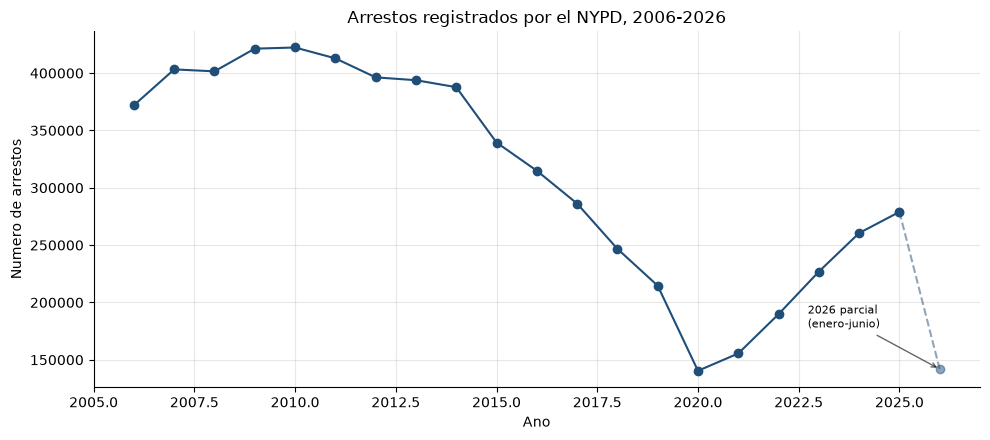

anio,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
Arrestos,371.934,403.231,401.529,421.316,422.322,412.859,396.280,393.809,387.727,339.470,...,286.225,246.773,214.617,140.413,155.507,189.774,226.872,260.503,278.953,141.870


In [25]:
serie = (arrestos.groupBy('anio').count()
         .orderBy('anio').toPandas().set_index('anio')['count'])

fig, ax = plt.subplots()
ax.plot(serie.index[:-1], serie.values[:-1], marker='o', color='#1f4e79')
ax.plot(serie.index[-2:], serie.values[-2:], marker='o', color='#1f4e79',
        linestyle='--', alpha=0.5)
ax.set_title('Arrestos registrados por el NYPD, 2006-2026')
ax.set_xlabel('Ano'); ax.set_ylabel('Numero de arrestos')
ax.ticklabel_format(style='plain', axis='y')
ax.annotate('2026 parcial\n(enero-junio)', xy=(serie.index[-1], serie.values[-1]),
            xytext=(-95, 30), textcoords='offset points', fontsize=8,
            arrowprops=dict(arrowstyle='->', alpha=0.6))
plt.tight_layout(); plt.show()

serie.apply(lambda v: format(v, ',').replace(',', '.')).to_frame('Arrestos').T


### Elemento 2. Arrestos por distrito: volumen absoluto frente a tasa poblacional

El volumen absoluto de arrestos favorece a los distritos más poblados y, por sí solo,
induce a error en la priorización territorial. Se normaliza el indicador por cada cien mil
habitantes, empleando como denominador la población estimada a partir de los pesos
muestrales del propio conjunto de pobreza.


In [26]:
# Poblacion por distrito derivada de los pesos muestrales de la encuesta
poblacion = (pobreza.groupBy('boro')
             .agg(F.sum('pwgtp').alias('poblacion'))
             .toPandas())
poblacion['distrito'] = poblacion['boro'].map(BORO_POBREZA)
poblacion = poblacion.set_index('distrito')['poblacion']

print('Poblacion estimada de la ciudad:',
      format(int(poblacion.sum()), ',').replace(',', '.'))
poblacion.apply(lambda v: format(int(v), ',').replace(',', '.')).to_frame('Habitantes')


/opt/cluster/spark/python/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


Poblacion estimada de la ciudad: 8.218.313


,Habitantes
distrito,
Bronx,1.389.245
Manhattan,1.568.288
Staten Island,469.393
Queens,2.250.749
Brooklyn,2.540.638


/opt/cluster/spark/python/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


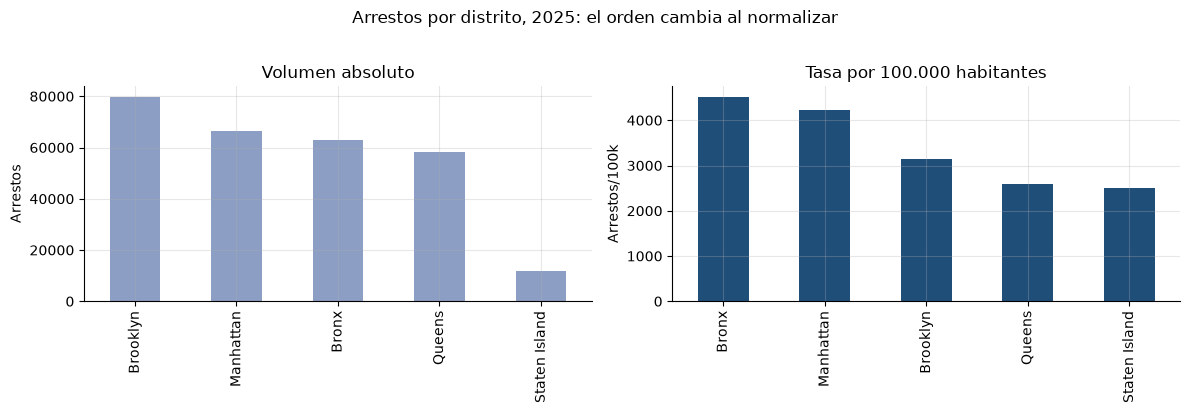

,Arrestos 2025,Poblacion,Por 100k hab
distrito,,,
Brooklyn,79882,2540638,3144.0
Manhattan,66448,1568288,4237.0
Bronx,62833,1389245,4523.0
Queens,58083,2250749,2581.0
Staten Island,11707,469393,2494.0


In [27]:
# Se emplea 2025, ultimo ano completo disponible
arr_2025 = (arrestos.filter(F.col('anio') == 2025)
            .groupBy('distrito').count().toPandas()
            .dropna().set_index('distrito')['count'])

comp = pd.DataFrame({'Arrestos 2025': arr_2025, 'Poblacion': poblacion})
comp['Por 100k hab'] = (100000 * comp['Arrestos 2025'] / comp['Poblacion']).round(0)
comp = comp.sort_values('Arrestos 2025', ascending=False)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
comp['Arrestos 2025'].plot.bar(ax=a1, color='#8c9ec4')
a1.set_title('Volumen absoluto'); a1.set_xlabel(''); a1.set_ylabel('Arrestos')
comp['Por 100k hab'].sort_values(ascending=False).plot.bar(ax=a2, color='#1f4e79')
a2.set_title('Tasa por 100.000 habitantes'); a2.set_xlabel(''); a2.set_ylabel('Arrestos/100k')
plt.suptitle('Arrestos por distrito, 2025: el orden cambia al normalizar', y=1.02)
plt.tight_layout(); plt.show()

comp


### Elemento 3. Composición de los arrestos por gravedad y tipo de delito


In [28]:
GRAVEDAD = {'F': 'Delito grave (felony)', 'M': 'Delito menor (misdemeanor)',
            'V': 'Contravencion (violation)', 'I': 'Infraccion'}

grav = (arrestos.groupBy('LAW_CAT_CD').count().toPandas()
        .assign(Categoria=lambda d: d['LAW_CAT_CD'].map(GRAVEDAD).fillna('Sin clasificar'))
        .groupby('Categoria')['count'].sum().sort_values(ascending=False))
grav_pct = (100 * grav / grav.sum()).round(2)
pd.DataFrame({'Arrestos': grav, '% del total': grav_pct})


/opt/cluster/spark/python/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


,Arrestos,% del total
Categoria,,
Delito menor (misdemeanor),4110313,64.15
Delito grave (felony),1934904,30.20
Contravencion (violation),303682,4.74
Sin clasificar,30444,0.48
Infraccion,27505,0.43


/opt/cluster/spark/python/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


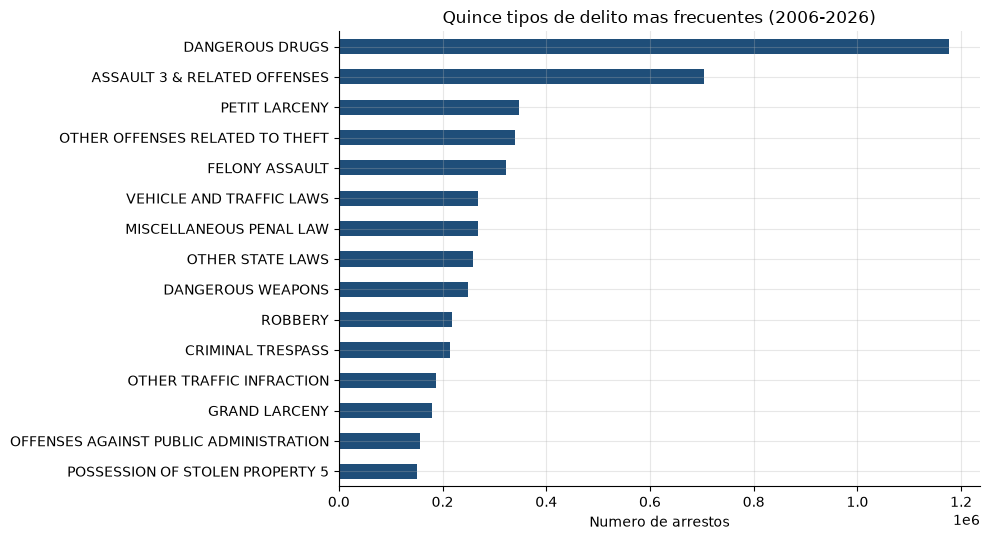

,Arrestos
OFNS_DESC,
DANGEROUS DRUGS,1177541
ASSAULT 3 & RELATED OFFENSES,705061
PETIT LARCENY,347258
OTHER OFFENSES RELATED TO THEFT,340186
FELONY ASSAULT,323220
VEHICLE AND TRAFFIC LAWS,267824
MISCELLANEOUS PENAL LAW,267818
OTHER STATE LAWS,258962
DANGEROUS WEAPONS,249016


In [29]:
top_delitos = (arrestos.filter(F.col('OFNS_DESC').isNotNull())
               .groupBy('OFNS_DESC').count()
               .orderBy(F.desc('count')).limit(15).toPandas()
               .set_index('OFNS_DESC')['count'])

fig, ax = plt.subplots(figsize=(10, 5.5))
top_delitos.sort_values().plot.barh(ax=ax, color='#1f4e79')
ax.set_title('Quince tipos de delito mas frecuentes (2006-2026)')
ax.set_xlabel('Numero de arrestos'); ax.set_ylabel('')
plt.tight_layout(); plt.show()

top_delitos.to_frame('Arrestos')


### Elemento 4. Perfil demográfico de las personas arrestadas


/opt/cluster/spark/python/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


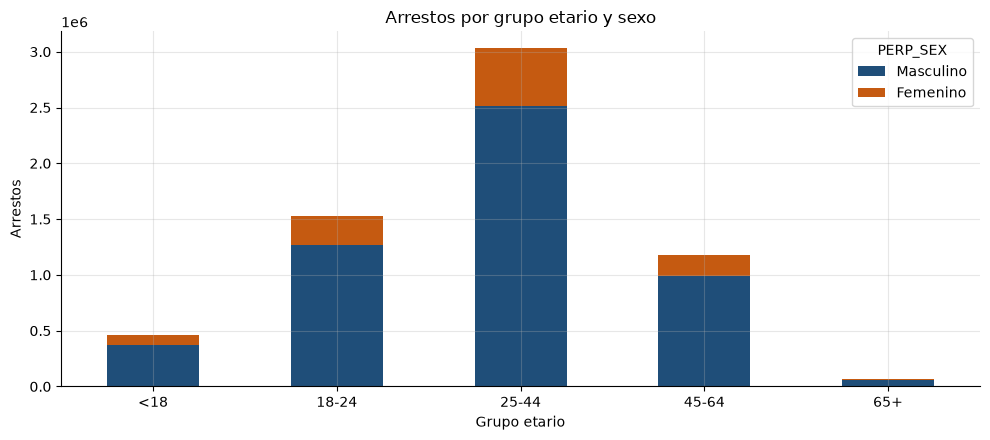

PERP_SEX,Femenino,Masculino,Total,% femenino
AGE_GROUP,,,,
<18,90515.0,367438.0,457953.0,19.77
18-24,259407.0,1270031.0,1529438.0,16.96
25-44,514080.0,2516916.0,3030996.0,16.96
45-64,187343.0,986923.0,1174266.0,15.95
65+,9271.0,53988.0,63259.0,14.66


In [30]:
demo = (arrestos.filter(F.col('PERP_SEX').isin('M', 'F'))
        .groupBy('AGE_GROUP', 'PERP_SEX').count().toPandas()
        .pivot(index='AGE_GROUP', columns='PERP_SEX', values='count')
        .rename(columns={'F': 'Femenino', 'M': 'Masculino'}))
orden = ['<18', '18-24', '25-44', '45-64', '65+']
demo = demo.reindex([o for o in orden if o in demo.index])
demo['Total'] = demo.sum(axis=1)
demo['% femenino'] = (100 * demo['Femenino'] / demo['Total']).round(2)

fig, ax = plt.subplots()
demo[['Masculino', 'Femenino']].plot.bar(ax=ax, stacked=True,
                                         color=['#1f4e79', '#c55a11'])
ax.set_title('Arrestos por grupo etario y sexo')
ax.set_xlabel('Grupo etario'); ax.set_ylabel('Arrestos')
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

demo


### Elemento 5. Concentración territorial: precintos con mayor número de arrestos

El precinto policial constituye la unidad geográfica más fina disponible en el conjunto de
arrestos, y resulta más útil que el distrito para orientar la asignación de recursos.


/opt/cluster/spark/python/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


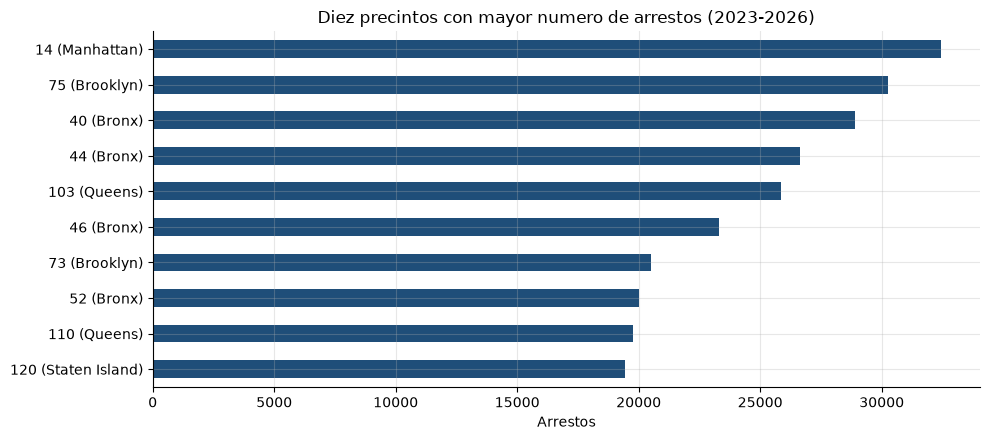

Los diez precintos concentran el 27.21% de los arrestos del periodo


,Arrestos
Precinto,
14 (Manhattan),32424
75 (Brooklyn),30274
40 (Bronx),28897
44 (Bronx),26648
103 (Queens),25842
46 (Bronx),23324
73 (Brooklyn),20498
52 (Bronx),20024
110 (Queens),19771


In [31]:
top_prec = (arrestos.filter(F.col('anio') >= 2023)
            .groupBy('ARREST_PRECINCT', 'distrito').count()
            .orderBy(F.desc('count')).limit(10).toPandas())
top_prec['Precinto'] = (top_prec['ARREST_PRECINCT'].astype('Int64').astype(str)
                        + ' (' + top_prec['distrito'].fillna('n/d') + ')')
s = top_prec.set_index('Precinto')['count']

fig, ax = plt.subplots()
s.sort_values().plot.barh(ax=ax, color='#1f4e79')
ax.set_title('Diez precintos con mayor numero de arrestos (2023-2026)')
ax.set_xlabel('Arrestos'); ax.set_ylabel('')
plt.tight_layout(); plt.show()

total_todos = arrestos.filter(F.col('anio') >= 2023).count()
print('Los diez precintos concentran el %.2f%% de los arrestos del periodo'
      % (100 * s.sum() / total_todos))
s.to_frame('Arrestos')


### Elemento 6. Estacionalidad y evolución de los siniestros viales


/opt/cluster/spark/python/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


/opt/cluster/spark/python/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


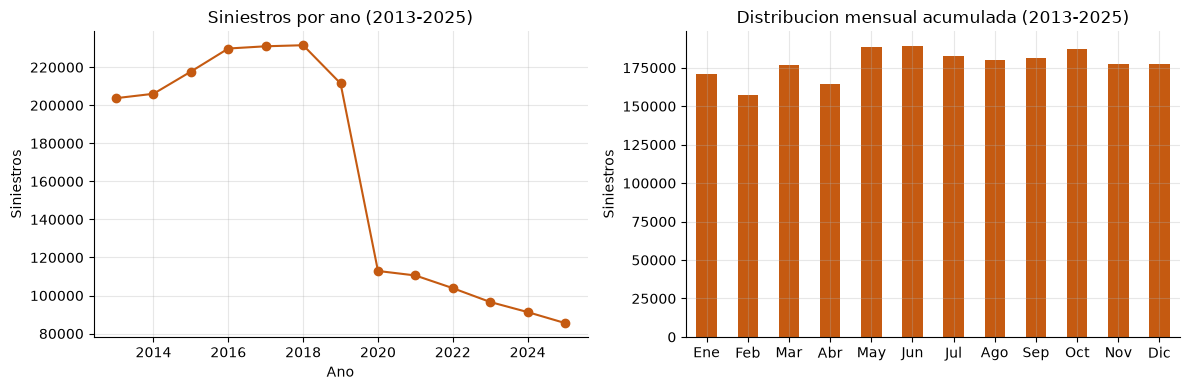

anio,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
Siniestros,100545,203742,206046,217708,229833,231007,231564,211486,112918,110558,103887,96607,91316,85546,36424


In [32]:
sin_anio = (siniestros.groupBy('anio').count().orderBy('anio').toPandas()
            .set_index('anio')['count'])
MESES = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun',
         'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
sin_mes = (siniestros.filter(F.col('anio').between(2013, 2025))
           .groupBy(F.month('crash_date').alias('mes')).count()
           .orderBy('mes').toPandas().set_index('mes')['count'])
sin_mes.index = MESES

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
a1.plot(sin_anio.index[1:-1], sin_anio.values[1:-1], marker='o', color='#c55a11')
a1.set_title('Siniestros por ano (2013-2025)'); a1.set_xlabel('Ano')
a1.set_ylabel('Siniestros')
sin_mes.plot.bar(ax=a2, color='#c55a11')
a2.set_title('Distribucion mensual acumulada (2013-2025)')
a2.set_xlabel(''); a2.set_ylabel('Siniestros')
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

pd.DataFrame({'Siniestros': sin_anio}).T


### Elemento 7. Distribución horaria de los siniestros

El atributo `crash_time` se almacena como texto en formato `H:MM`. Se extrae la hora para
identificar las franjas de mayor exposición al riesgo.


/opt/cluster/spark/python/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


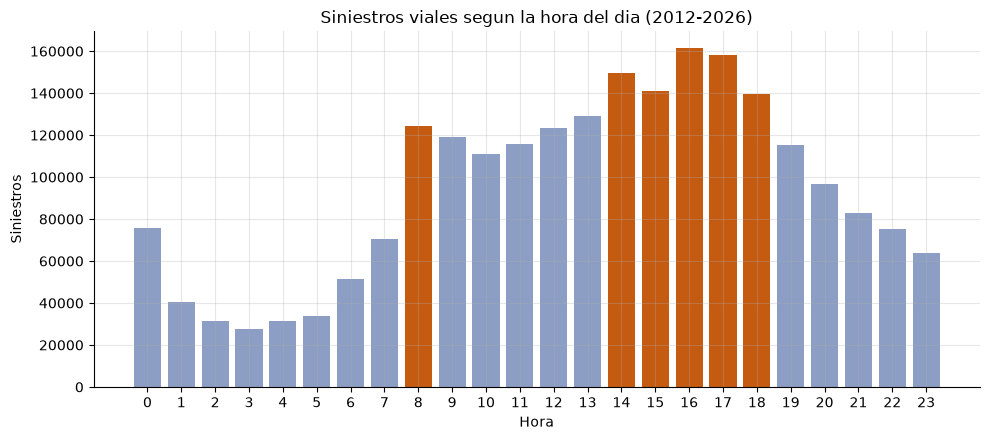

Franja de mayor incidencia: 16:00 horas, con 161.385 siniestros


hora,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
Siniestros,75806,40498,31269,27571,31321,33878,51553,70581,124228,118950,...,149385,141172,161385,158232,139496,115262,96751,82841,75404,63665


In [33]:
por_hora = (siniestros
            .withColumn('hora', F.split('crash_time', ':').getItem(0).cast('int'))
            .filter(F.col('hora').between(0, 23))
            .groupBy('hora').count().orderBy('hora').toPandas()
            .set_index('hora')['count'])

fig, ax = plt.subplots()
colores = ['#c55a11' if h in (8, 14, 15, 16, 17, 18) else '#8c9ec4'
           for h in por_hora.index]
ax.bar(por_hora.index, por_hora.values, color=colores)
ax.set_title('Siniestros viales segun la hora del dia (2012-2026)')
ax.set_xlabel('Hora'); ax.set_ylabel('Siniestros'); ax.set_xticks(range(0, 24))
plt.tight_layout(); plt.show()

print('Franja de mayor incidencia: %d:00 horas, con %s siniestros'
      % (por_hora.idxmax(), format(int(por_hora.max()), ',').replace(',', '.')))
por_hora.to_frame('Siniestros').T


### Elemento 8. Gravedad de los siniestros por distrito

Se contrastan el volumen de siniestros, las víctimas y la letalidad, normalizando
nuevamente por población. El análisis se restringe a los registros que cuentan con distrito
informado, circunstancia que afecta al 30,5% del conjunto y que se aborda en el apartado de
limpieza.


/opt/cluster/spark/python/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


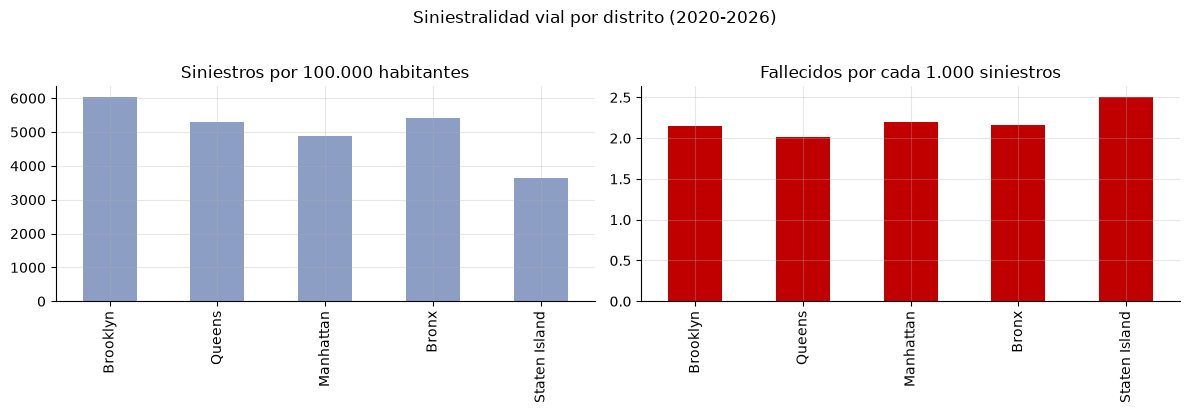

,Siniestros,Heridos,Fallecidos,Peatones fallecidos,Ciclistas fallecidos,Poblacion,Siniestros/100k,Letalidad (x1000 sin.)
distrito,,,,,,,,
Brooklyn,153694,77700,331,173,36,2540638,6049.0,2.15
Queens,119277,56717,240,114,21,2250749,5299.0,2.01
Manhattan,76529,33729,168,103,31,1568288,4880.0,2.20
Bronx,75309,37233,163,62,21,1389245,5421.0,2.16
Staten Island,17098,7833,43,20,1,469393,3643.0,2.51


In [34]:
grav_sin = (siniestros.filter(F.col('borough').isNotNull() & (F.col('anio') >= 2020))
            .groupBy('borough')
            .agg(F.count('*').alias('Siniestros'),
                 F.sum('n_persons_injured').alias('Heridos'),
                 F.sum('n_persons_killed').alias('Fallecidos'),
                 F.sum('n_pedestrians_killed').alias('Peatones fallecidos'),
                 F.sum('n_cyclist_killed').alias('Ciclistas fallecidos'))
            .toPandas())
grav_sin['distrito'] = grav_sin['borough'].str.title().replace({'Staten Island': 'Staten Island'})
grav_sin = grav_sin.set_index('distrito').drop(columns='borough')
grav_sin['Poblacion'] = poblacion
grav_sin['Siniestros/100k'] = (100000 * grav_sin['Siniestros'] / grav_sin['Poblacion']).round(0)
grav_sin['Letalidad (x1000 sin.)'] = (1000 * grav_sin['Fallecidos'] / grav_sin['Siniestros']).round(2)
grav_sin = grav_sin.sort_values('Siniestros', ascending=False)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
grav_sin['Siniestros/100k'].plot.bar(ax=a1, color='#8c9ec4')
a1.set_title('Siniestros por 100.000 habitantes'); a1.set_xlabel('')
grav_sin['Letalidad (x1000 sin.)'].plot.bar(ax=a2, color='#c00000')
a2.set_title('Fallecidos por cada 1.000 siniestros'); a2.set_xlabel('')
plt.suptitle('Siniestralidad vial por distrito (2020-2026)', y=1.02)
plt.tight_layout(); plt.show()

grav_sin


### Elemento 9. Factores contribuyentes declarados en los siniestros


/opt/cluster/spark/python/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


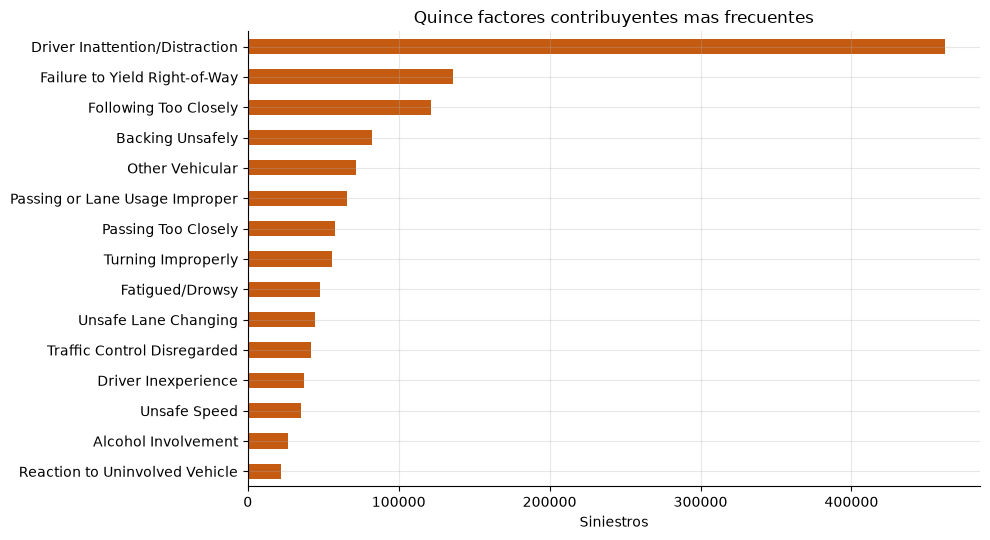

Registros con factor no especificado: 756.643 (33.3% del total)


,Siniestros
factor_1,
Driver Inattention/Distraction,462105
Failure to Yield Right-of-Way,136046
Following Too Closely,121711
Backing Unsafely,82577
Other Vehicular,71429
Passing or Lane Usage Improper,65544
Passing Too Closely,58028
Turning Improperly,55751
Fatigued/Drowsy,47599


In [35]:
factores = (siniestros.filter(F.col('factor_1').isNotNull() &
                              (F.col('factor_1') != 'Unspecified'))
            .groupBy('factor_1').count()
            .orderBy(F.desc('count')).limit(15).toPandas()
            .set_index('factor_1')['count'])

fig, ax = plt.subplots(figsize=(10, 5.5))
factores.sort_values().plot.barh(ax=ax, color='#c55a11')
ax.set_title('Quince factores contribuyentes mas frecuentes')
ax.set_xlabel('Siniestros'); ax.set_ylabel('')
plt.tight_layout(); plt.show()

sin_espec = siniestros.filter(F.col('factor_1') == 'Unspecified').count()
print('Registros con factor no especificado: %s (%.1f%% del total)'
      % (format(sin_espec, ',').replace(',', '.'),
         100 * sin_espec / siniestros.count()))
factores.to_frame('Siniestros')


### Elemento 10. Los datos ausentes como fenómeno temporal

El conjunto *Vehicles* presenta más de la mitad de los registros sin sexo del conductor ni
estado de la licencia. La hipótesis que se pone a prueba es que dicha ausencia no obedece a
un deterioro aleatorio de la calidad, sino a la modificación del formulario de captura
introducida en un momento determinado. De confirmarse, la estrategia de tratamiento no debe
ser la imputación, sino la restricción de la ventana temporal de análisis.


/opt/cluster/spark/python/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


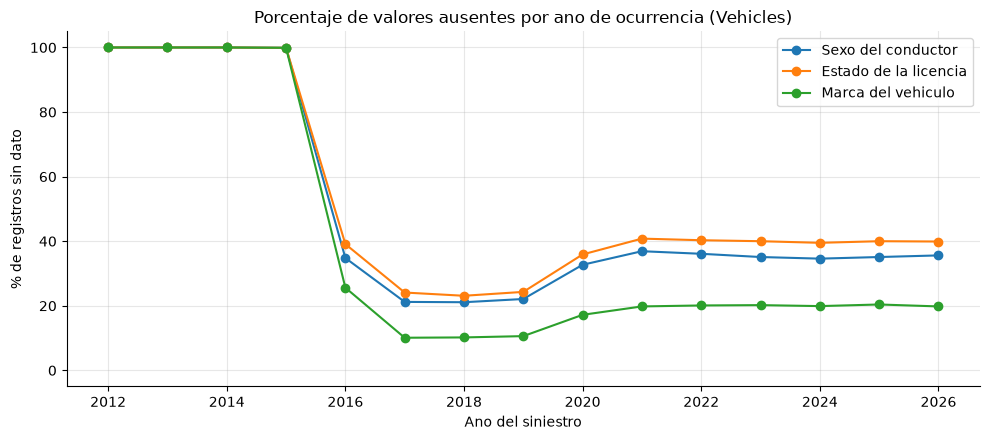

,registros,% sin_sexo,% sin_licencia,% sin_marca
anio,,,,
2012,198968,100.0,100.0,100.0
2013,404702,100.0,100.0,100.0
2014,409087,100.0,100.0,100.0
2015,434607,99.9,99.9,99.9
2016,457944,34.8,39.1,25.6
2017,464544,21.2,24.1,10.1
2018,465822,21.1,23.1,10.2
2019,426724,22.1,24.3,10.6
2020,231211,32.7,35.9,17.2


In [36]:
calidad_anual = (vehiculos
                 .withColumn('anio', F.year('crash_date'))
                 .filter(F.col('anio').between(2012, 2026))
                 .groupBy('anio')
                 .agg(F.count('*').alias('registros'),
                      F.count(F.when(F.col('driver_sex').isNull(), 1)).alias('sin_sexo'),
                      F.count(F.when(F.col('driver_license_status').isNull(), 1)).alias('sin_licencia'),
                      F.count(F.when(F.col('vehicle_make').isNull(), 1)).alias('sin_marca'))
                 .orderBy('anio').toPandas().set_index('anio'))

for c in ['sin_sexo', 'sin_licencia', 'sin_marca']:
    calidad_anual['% ' + c] = (100 * calidad_anual[c] / calidad_anual['registros']).round(1)

fig, ax = plt.subplots()
for c, et in [('% sin_sexo', 'Sexo del conductor'),
              ('% sin_licencia', 'Estado de la licencia'),
              ('% sin_marca', 'Marca del vehiculo')]:
    ax.plot(calidad_anual.index, calidad_anual[c], marker='o', label=et)
ax.set_title('Porcentaje de valores ausentes por ano de ocurrencia (Vehicles)')
ax.set_xlabel('Ano del siniestro'); ax.set_ylabel('% de registros sin dato')
ax.set_ylim(-5, 105); ax.legend()
plt.tight_layout(); plt.show()

calidad_anual[['registros', '% sin_sexo', '% sin_licencia', '% sin_marca']]


### Elemento 11. Pobreza por distrito

Las estimaciones se calculan ponderando por el factor de expansión `pwgtp`. Omitir esa
ponderación produciría cifras sesgadas, dado que la muestra no es autoponderada.


/opt/cluster/spark/python/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


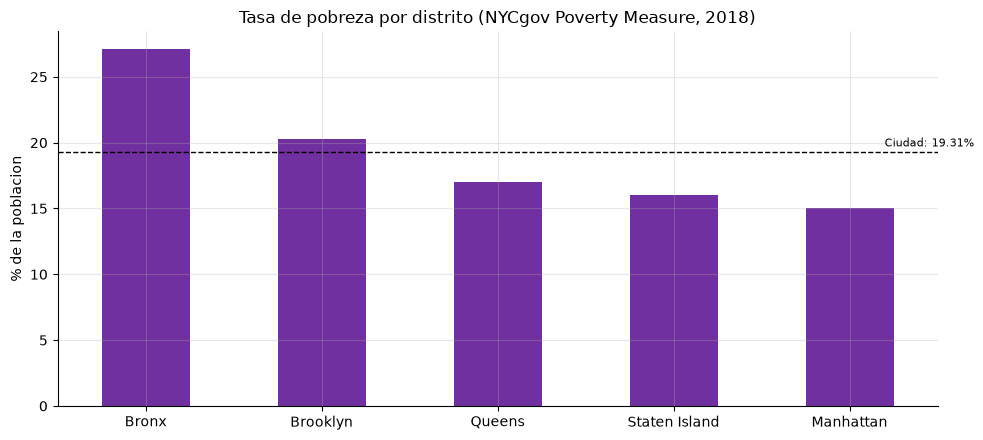

,Poblacion,En pobreza,Tasa de pobreza (%)
distrito,,,
Bronx,1389245,376487,27.10
Brooklyn,2540638,516035,20.31
Queens,2250749,383134,17.02
Staten Island,469393,75086,16.00
Manhattan,1568288,236151,15.06


In [37]:
pob_dist = (pobreza.groupBy('boro')
            .agg(F.sum('pwgtp').alias('Poblacion'),
                 F.sum(F.when(F.col('nycgov_pov_stat') == 1, F.col('pwgtp'))
                        .otherwise(0)).alias('En pobreza'))
            .toPandas())
pob_dist['distrito'] = pob_dist['boro'].map(BORO_POBREZA)
pob_dist = pob_dist.set_index('distrito').drop(columns='boro')
pob_dist['Tasa de pobreza (%)'] = (100 * pob_dist['En pobreza'] / pob_dist['Poblacion']).round(2)
pob_dist = pob_dist.sort_values('Tasa de pobreza (%)', ascending=False)

fig, ax = plt.subplots()
pob_dist['Tasa de pobreza (%)'].plot.bar(ax=ax, color='#7030a0')
tasa_ciudad = 100 * pob_dist['En pobreza'].sum() / pob_dist['Poblacion'].sum()
ax.axhline(tasa_ciudad, color='black', linestyle='--', linewidth=1)
ax.text(4.2, tasa_ciudad + 0.4, 'Ciudad: %.2f%%' % tasa_ciudad, fontsize=8)
ax.set_title('Tasa de pobreza por distrito (NYCgov Poverty Measure, 2018)')
ax.set_xlabel(''); ax.set_ylabel('% de la poblacion')
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

pob_dist


### Elemento 12. Desempeño educativo por distrito

El identificador `DBN` codifica el distrito en su tercer carácter, lo que permite vincular
el conjunto educativo con el resto del análisis territorial. Se excluyen las instituciones
cuyos puntajes fueron suprimidos.


/opt/cluster/spark/python/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


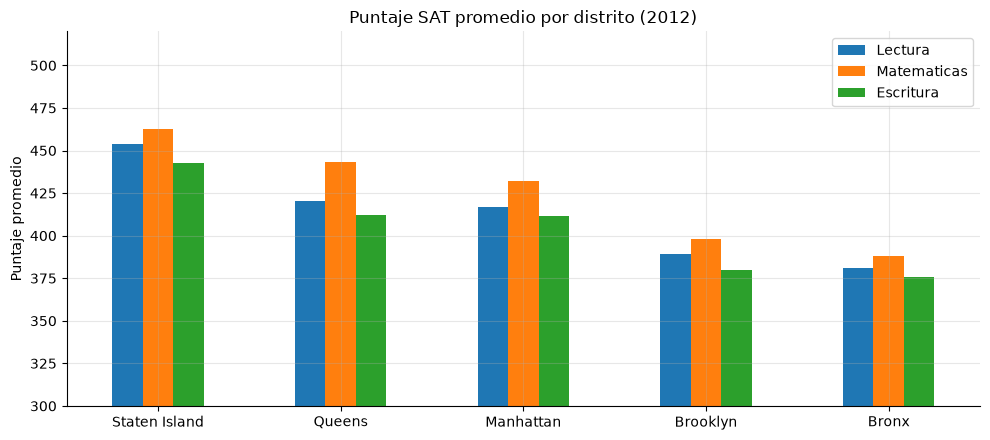

,Instituciones,Evaluados,Lectura,Matematicas,Escritura,Total SAT
distrito,,,,,,
Staten Island,12,3025,453.8,462.9,442.4,1359.1
Queens,70,12319,420.1,443.2,412.1,1275.4
Manhattan,106,10312,416.6,432.3,411.3,1260.2
Brooklyn,123,13169,389.0,398.2,380.1,1167.3
Bronx,110,7620,380.9,387.8,376.0,1144.7


In [38]:
BORO_DBN = {'X': 'Bronx', 'K': 'Brooklyn', 'M': 'Manhattan',
            'Q': 'Queens', 'R': 'Staten Island'}
expr_dbn = F.create_map([F.lit(x) for kv in BORO_DBN.items() for x in kv])

sat_limpio = (sat.filter(F.col('sat_matematicas').rlike('^[0-9]+$'))
              .withColumn('distrito', expr_dbn[F.substring('dbn', 3, 1)])
              .withColumn('lectura', F.col('sat_lectura').cast('int'))
              .withColumn('matematicas', F.col('sat_matematicas').cast('int'))
              .withColumn('escritura', F.col('sat_escritura').cast('int'))
              .withColumn('evaluados', F.col('n_evaluados').cast('int')))

sat_dist = (sat_limpio.groupBy('distrito')
            .agg(F.count('*').alias('Instituciones'),
                 F.sum('evaluados').alias('Evaluados'),
                 F.round(F.avg('lectura'), 1).alias('Lectura'),
                 F.round(F.avg('matematicas'), 1).alias('Matematicas'),
                 F.round(F.avg('escritura'), 1).alias('Escritura'))
            .toPandas().dropna(subset=['distrito']).set_index('distrito'))
sat_dist['Total SAT'] = sat_dist[['Lectura', 'Matematicas', 'Escritura']].sum(axis=1).round(1)
sat_dist = sat_dist.sort_values('Total SAT', ascending=False)

fig, ax = plt.subplots()
sat_dist[['Lectura', 'Matematicas', 'Escritura']].plot.bar(ax=ax)
ax.set_title('Puntaje SAT promedio por distrito (2012)')
ax.set_xlabel(''); ax.set_ylabel('Puntaje promedio'); ax.set_ylim(300, 520)
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

sat_dist


### Elemento 13. Convergencia territorial de los indicadores

Se consolidan en una sola tabla los indicadores construidos, lo que permite apreciar si los
distritos con mayor incidencia de arrestos y siniestros coinciden con aquellos de mayor
pobreza y menor desempeño educativo. Se trata de una descripción conjunta y no de una
relación causal; su contrastación formal corresponde a la entrega final.


In [39]:
panel = pd.DataFrame({
    'Arrestos/100k (2025)': comp['Por 100k hab'],
    'Siniestros/100k (2020-26)': grav_sin['Siniestros/100k'],
    'Letalidad (x1000)': grav_sin['Letalidad (x1000 sin.)'],
    'Pobreza (%)': pob_dist['Tasa de pobreza (%)'],
    'SAT total (2012)': sat_dist['Total SAT'],
    'Poblacion': poblacion.astype('int64'),
})
panel = panel.sort_values('Arrestos/100k (2025)', ascending=False)
panel


,Arrestos/100k (2025),Siniestros/100k (2020-26),Letalidad (x1000),Pobreza (%),SAT total (2012),Poblacion
distrito,,,,,,
Bronx,4523.0,5421.0,2.16,27.10,1144.7,1389245
Manhattan,4237.0,4880.0,2.20,15.06,1260.2,1568288
Brooklyn,3144.0,6049.0,2.15,20.31,1167.3,2540638
Queens,2581.0,5299.0,2.01,17.02,1275.4,2250749
Staten Island,2494.0,3643.0,2.51,16.00,1359.1,469393


In [40]:
# Ordenamiento de los distritos segun cada indicador
rank = pd.DataFrame({
    'Arrestos': panel['Arrestos/100k (2025)'].rank(ascending=False).astype(int),
    'Siniestros': panel['Siniestros/100k (2020-26)'].rank(ascending=False).astype(int),
    'Pobreza': panel['Pobreza (%)'].rank(ascending=False).astype(int),
    'SAT (menor puntaje)': panel['SAT total (2012)'].rank(ascending=True).astype(int),
})
print('Posicion 1 = situacion mas desfavorable en cada indicador')
rank


Posicion 1 = situacion mas desfavorable en cada indicador


,Arrestos,Siniestros,Pobreza,SAT (menor puntaje)
distrito,,,,
Bronx,1,2,1,1
Manhattan,2,4,5,3
Brooklyn,3,1,2,2
Queens,4,3,3,4
Staten Island,5,5,4,5


---

*El cuaderno continúa en la entrega final con el planteamiento y la resolución de las
preguntas de negocio, así como con el proceso completo de limpieza y transformación.*
